# Fast Sentiment Analysis Using Distilled Transformers on CPU
### Final Report — Weeks 3 & 4 Experiments

| | |
|---|---|
| **Task** | Binary sentiment classification (Positive / Negative) |
| **Datasets** | SST-2 (GLUE, full: 67,349 train / 872 val) · IMDb (full: 25,000 train / 25,000 test) |
| **Models** | (1) LR + TF-IDF · (2) BiLSTM · (3) DistilBERT FP32 · (4) DistilBERT INT8 |
| **Scope** | CPU-only inference · No GPU required |
| **Authors** | Arwa Elgazar (Student A) · Eman Elsayed (Student B) · Esraa Nematalla (Student C) |

---




---
## §1 · Setup & Reproducibility

In [1]:
# §1.1  Install / verify dependencies
import subprocess, sys

required = [
    "torch",
    "transformers>=4.36.0",
    "datasets",
    "accelerate>=0.26.0",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "psutil",
]

for pkg in required:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

print("✓ All packages ready")

✓ All packages ready


In [2]:
# §1.2  Global imports
import os, io, time, warnings, random, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import load_dataset, Dataset

warnings.filterwarnings("ignore")

print("✓ Imports complete")
import transformers, sklearn, datasets as ds_lib
print(f"  torch          : {torch.__version__}")
print(f"  transformers   : {transformers.__version__}")
print(f"  scikit-learn   : {sklearn.__version__}")
print(f"  datasets       : {ds_lib.__version__}")

c:\Users\DPquai250107\AppData\Local\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete
  torch          : 2.12.0+cpu
  transformers   : 4.57.1
  scikit-learn   : 1.8.0
  datasets       : 3.6.0


In [3]:
# §1.3  Reproducibility — fix ALL random seeds
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# Project-wide configuration (FINAL — full datasets)
CFG = {
    # DistilBERT
    "model_name"         : "distilbert-base-uncased",
    "max_seq_len_sst2"   : 64,     # 100% token coverage for SST-2
    "max_seq_len_imdb"   : 256,    # best latency/coverage trade-off for IMDb
    "train_epochs"       : 3,      # +1 epoch vs midterm
    "train_batch_size"   : 16,
    "eval_batch_size"    : 64,
    "learning_rate"      : 2e-5,
    "weight_decay"       : 0.01,
    "warmup_ratio"       : 0.06,
    # TF-IDF
    "tfidf_max_features" : 50_000,
    "tfidf_ngram_range"  : (1, 2),
    "logreg_C"           : 1.0,
    "logreg_max_iter"    : 1000,
    # BiLSTM
    "lstm_embed_dim"     : 100,
    "lstm_hidden_dim"    : 128,
    "lstm_num_layers"    : 2,
    "lstm_dropout"       : 0.3,
    "lstm_epochs"        : 5,
    "lstm_batch_size"    : 64,
    "lstm_lr"            : 1e-3,
    "lstm_max_vocab"     : 20_000,
    "lstm_max_seq_len"   : 64,
    # Efficiency measurement
    "n_warmup_runs"      : 5,
    "n_timing_runs"      : 100,
    # Paths
    "output_dir_sst2"    : "./distilbert_sst2_final",
    "output_dir_imdb"    : "./distilbert_imdb_final",
    "results_dir"        : "./results_final",
}

for d in [CFG["output_dir_sst2"], CFG["output_dir_imdb"], CFG["results_dir"]]:
    os.makedirs(d, exist_ok=True)

ID2LABEL = {0: "NEGATIVE", 1: "POSITIVE"}
LABEL2ID = {"NEGATIVE": 0, "POSITIVE": 1}

print(f"✓ Seed fixed to {SEED}")
print(f"  Device: {'CUDA — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (project scope)'}")

✓ Seed fixed to 42
  Device: CPU (project scope)


---
## §2 · Formal Metric Definitions

> **Addresses grader note:** *"No metric is formally defined with a mathematical equation."*

Let $y_i \in \{0,1\}$ be the true label and $\hat{y}_i$ the predicted label for sample $i$, with $N$ total test samples.

**True Positives / Negatives / False Positives / Negatives** for class $c$:

$$TP_c = \sum_{i=1}^{N} \mathbf{1}[y_i = c \;\wedge\; \hat{y}_i = c]$$

**Accuracy** — fraction of correctly classified samples:
$$\text{Accuracy} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}[y_i = \hat{y}_i]$$

**Precision** for class $c$:
$$P_c = \frac{TP_c}{TP_c + FP_c}$$

**Recall** for class $c$:
$$R_c = \frac{TP_c}{TP_c + FN_c}$$

**F1-score** for class $c$ (harmonic mean of precision and recall):
$$F1_c = 2 \cdot \frac{P_c \cdot R_c}{P_c + R_c}$$

**Macro-F1** — unweighted mean over all classes $C$:
$$\text{Macro-F1} = \frac{1}{|C|} \sum_{c \in C} F1_c$$

**Inference latency** — median wall-clock time per sample over $T$ timed runs after $W$ warm-up runs:
$$\text{Latency} = \text{median}_{t=1}^{T}\left(\frac{\Delta t_t}{B}\right), \quad B=1$$

**Model size** — total non-zero parameter bytes:
$$\text{Size (MB)} = \frac{\sum_{l} |\theta_l| \cdot b_l}{1024^2}$$
where $|\theta_l|$ is the number of elements in layer $l$ and $b_l$ is bytes-per-element (4 for FP32, 1 for INT8).

**Compression ratio** (FP32 → INT8):
$$\rho = \frac{\text{Size}_{\text{FP32}}}{\text{Size}_{\text{INT8}}}$$

---
## §3 · Data Loading & EDA — Full Datasets

> **Final report uses full datasets** — SST-2 (67,349 train / 872 validation) and IMDb (25,000 train / 25,000 test).

In [4]:
# §3.1  Load SST-2 (full dataset)
print("Loading SST-2 (GLUE) — full dataset …")
sst2 = load_dataset("glue", "sst2")

train_sst2 = sst2["train"]
val_sst2   = sst2["validation"]

print(f"  Train : {len(train_sst2):,} samples")
print(f"  Val   : {len(val_sst2):,} samples")
print(f"  Sample: '{train_sst2[0]['sentence']}' → {ID2LABEL[train_sst2[0]['label']]}")

Loading SST-2 (GLUE) — full dataset …
  Train : 67,349 samples
  Val   : 872 samples
  Sample: 'hide new secretions from the parental units ' → NEGATIVE


In [5]:
# §3.2  Load IMDb (full dataset)
import html

def clean_imdb(text: str) -> str:
    """Decode HTML entities, strip tags, lowercase, collapse whitespace."""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Loading IMDb — full dataset …")
imdb_raw = load_dataset("imdb")

# Apply cleaning
train_imdb_texts  = [clean_imdb(t) for t in imdb_raw["train"]["text"]]
train_imdb_labels = imdb_raw["train"]["label"]
test_imdb_texts   = [clean_imdb(t) for t in imdb_raw["test"]["text"]]
test_imdb_labels  = imdb_raw["test"]["label"]

print(f"  Train : {len(train_imdb_texts):,} samples")
print(f"  Test  : {len(test_imdb_texts):,} samples")
print(f"  Sample (first 100 chars): '{train_imdb_texts[0][:100]}…'")

Loading IMDb — full dataset …


Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 339719.33 examples/s]


  Train : 25,000 samples
  Test  : 25,000 samples
  Sample (first 100 chars): 'i rented i am curious-yellow from my video store because of all the controversy that surrounded it w…'


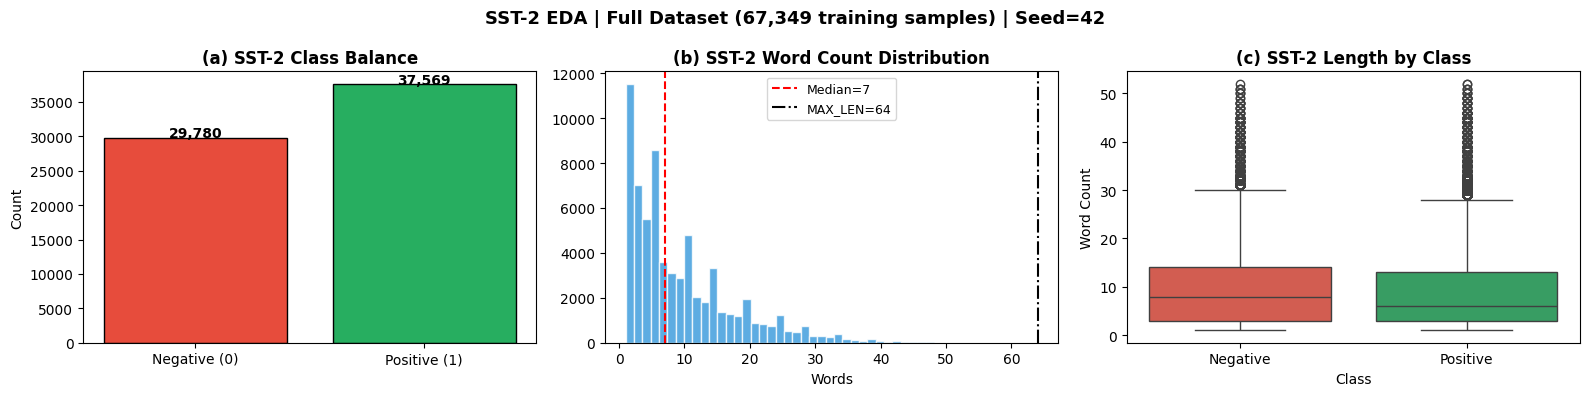

SST-2 statistics:
            count  mean  std  min  25%  50%   75%   max
Class                                                  
Negative  29780.0   9.9  8.2  1.0  3.0  8.0  14.0  52.0
Positive  37569.0   9.0  8.0  1.0  3.0  6.0  13.0  52.0


In [6]:
# §3.3  EDA — SST-2
sst2_df = train_sst2.to_pandas()
sst2_df["word_count"] = sst2_df["sentence"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = sst2_df["label"].value_counts().sort_index()
axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,
            color=["#e74c3c", "#27ae60"], edgecolor="black")
axes[0].set_title("(a) SST-2 Class Balance", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

axes[1].hist(sst2_df["word_count"], bins=40, color="#3498db", edgecolor="white", alpha=0.8)
axes[1].axvline(sst2_df["word_count"].median(), color="red", linestyle="--",
                label=f'Median={sst2_df["word_count"].median():.0f}')
axes[1].axvline(CFG["max_seq_len_sst2"], color="black", linestyle="-.",
                label=f'MAX_LEN={CFG["max_seq_len_sst2"]}')
axes[1].set_title("(b) SST-2 Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].legend(fontsize=9)

sst2_df["Class"] = sst2_df["label"].map({0: "Negative", 1: "Positive"})
sns.boxplot(data=sst2_df, x="Class", y="word_count",
            palette={"Negative": "#e74c3c", "Positive": "#27ae60"}, ax=axes[2])
axes[2].set_title("(c) SST-2 Length by Class", fontweight="bold")
axes[2].set_ylabel("Word Count")

plt.suptitle(f"SST-2 EDA | Full Dataset ({len(train_sst2):,} training samples) | Seed={SEED}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/sst2_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print("SST-2 statistics:")
print(sst2_df.groupby("Class")["word_count"].describe().round(1))

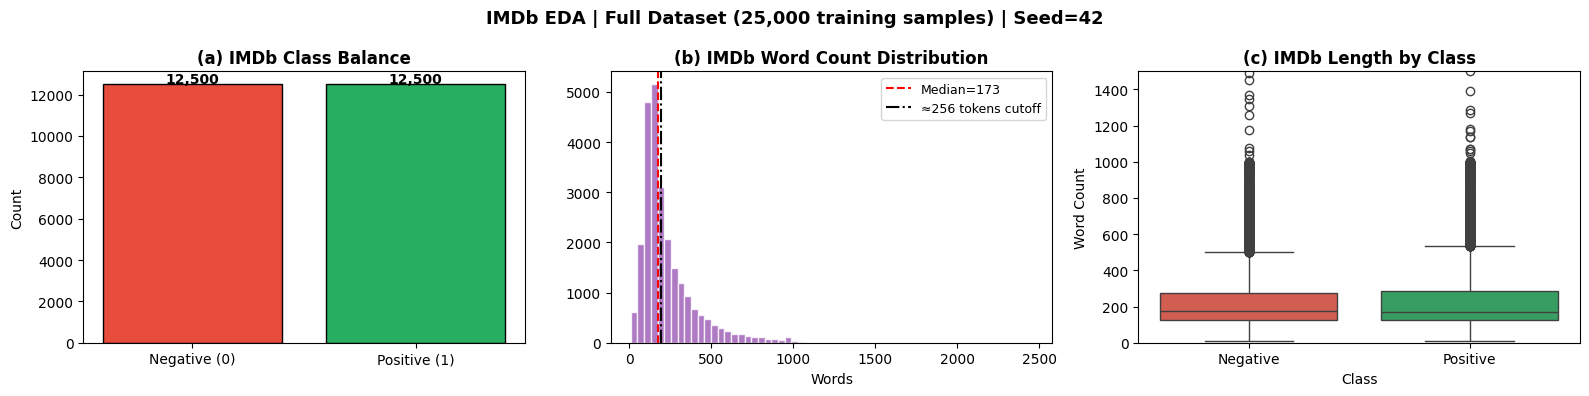

IMDb statistics:
            count   mean    std   min    25%    50%    75%     max
Class                                                             
Negative  12500.0  228.5  164.9  10.0  127.0  173.0  276.0  1491.0
Positive  12500.0  234.5  178.8  12.0  124.0  172.0  288.0  2459.0


In [7]:
# §3.4  EDA — IMDb
imdb_df = pd.DataFrame({"text": train_imdb_texts, "label": train_imdb_labels})
imdb_df["word_count"] = imdb_df["text"].str.split().str.len()
imdb_df["Class"]      = imdb_df["label"].map({0: "Negative", 1: "Positive"})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = imdb_df["label"].value_counts().sort_index()
axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,
            color=["#e74c3c", "#27ae60"], edgecolor="black")
axes[0].set_title("(a) IMDb Class Balance", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

axes[1].hist(imdb_df["word_count"], bins=60, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[1].axvline(imdb_df["word_count"].median(), color="red", linestyle="--",
                label=f'Median={imdb_df["word_count"].median():.0f}')
axes[1].axvline(CFG["max_seq_len_imdb"] / 1.3, color="black", linestyle="-.",
                label=f'≈256 tokens cutoff')
axes[1].set_title("(b) IMDb Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].legend(fontsize=9)

sns.boxplot(data=imdb_df, x="Class", y="word_count",
            palette={"Negative": "#e74c3c", "Positive": "#27ae60"}, ax=axes[2])
axes[2].set_title("(c) IMDb Length by Class", fontweight="bold")
axes[2].set_ylabel("Word Count")
axes[2].set_ylim(0, 1500)  # clip outliers for readability

plt.suptitle(f"IMDb EDA | Full Dataset ({len(train_imdb_texts):,} training samples) | Seed={SEED}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/imdb_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print("IMDb statistics:")
print(imdb_df.groupby("Class")["word_count"].describe().round(1))

---
## §4 · Preprocessing Pipelines

Two independent pipelines are maintained throughout (applying identical preprocessing to both
models would unfairly disadvantage the transformer, which was pre-trained on raw text).

| Pipeline | Steps |
|----------|-------|
| **Classical / BiLSTM** | lowercase → collapse whitespace · TF-IDF vectorisation OR integer vocab encoding |
| **DistilBERT** | Raw WordPiece tokenisation via `distilbert-base-uncased` · Dynamic per-batch padding |

In [8]:
# §4.1  Classical preprocessing — SST-2
def clean_text(text: str) -> str:
    """Minimal normalisation for TF-IDF / BiLSTM. Preserves negation punctuation."""
    return re.sub(r"\s+", " ", text.lower().strip())

X_train_sst2 = [clean_text(s) for s in train_sst2["sentence"]]
X_val_sst2   = [clean_text(s) for s in val_sst2["sentence"]]
y_train_sst2 = list(train_sst2["label"])
y_val_sst2   = list(val_sst2["label"])

# Classical preprocessing — IMDb
# clean_imdb() already applied during loading
from sklearn.model_selection import train_test_split

# Split IMDb train → 80/20 for validation
(X_train_imdb, X_val_imdb,
 y_train_imdb, y_val_imdb) = train_test_split(
    train_imdb_texts, list(train_imdb_labels),
    test_size=0.20, random_state=SEED, stratify=train_imdb_labels
)
X_test_imdb  = test_imdb_texts
y_test_imdb  = list(test_imdb_labels)

print(f"SST-2 — train: {len(X_train_sst2):,} | val: {len(X_val_sst2):,}")
print(f"IMDb  — train: {len(X_train_imdb):,} | val: {len(X_val_imdb):,} | test: {len(X_test_imdb):,}")

SST-2 — train: 67,349 | val: 872
IMDb  — train: 20,000 | val: 5,000 | test: 25,000


In [9]:
# §4.2  DistilBERT tokenisation
print(f"Loading DistilBERT tokenizer: {CFG['model_name']} …")
tokenizer = DistilBertTokenizerFast.from_pretrained(CFG["model_name"])
print(f"✓ Tokenizer ready  (vocab size = {tokenizer.vocab_size:,})")

def make_tokenize_fn(max_len):
    def tokenize_batch(batch):
        key = "sentence" if "sentence" in batch else "text"
        return tokenizer(batch[key], truncation=True, max_length=max_len, padding=False)
    return tokenize_batch

# SST-2 HuggingFace Dataset objects
tok_fn_sst2 = make_tokenize_fn(CFG["max_seq_len_sst2"])
train_sst2_tok = train_sst2.map(tok_fn_sst2, batched=True, remove_columns=["sentence", "idx"])
val_sst2_tok   = val_sst2.map(tok_fn_sst2,   batched=True, remove_columns=["sentence", "idx"])
train_sst2_tok.set_format("torch")
val_sst2_tok.set_format("torch")

# IMDb HuggingFace Dataset objects
tok_fn_imdb = make_tokenize_fn(CFG["max_seq_len_imdb"])
train_imdb_hf = Dataset.from_dict({"text": X_train_imdb, "label": y_train_imdb})
val_imdb_hf   = Dataset.from_dict({"text": X_val_imdb,   "label": y_val_imdb})
test_imdb_hf  = Dataset.from_dict({"text": X_test_imdb,  "label": y_test_imdb})

train_imdb_tok = train_imdb_hf.map(tok_fn_imdb, batched=True, remove_columns=["text"])
val_imdb_tok   = val_imdb_hf.map(tok_fn_imdb,   batched=True, remove_columns=["text"])
test_imdb_tok  = test_imdb_hf.map(tok_fn_imdb,  batched=True, remove_columns=["text"])
train_imdb_tok.set_format("torch")
val_imdb_tok.set_format("torch")
test_imdb_tok.set_format("torch")

collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✓ All tokenisation complete")

Loading DistilBERT tokenizer: distilbert-base-uncased …
✓ Tokenizer ready  (vocab size = 30,522)


Map: 100%|██████████| 25000/25000 [00:04<00:00, 5209.18 examples/s]

✓ All tokenisation complete


---
## §5 · Classical Baseline: Logistic Regression + TF-IDF

**Student A (Arwa Elgazar)**

In [11]:
# §5.0  Shared efficiency-measurement utilities

def measure_latency_sklearn(pipeline, X_sample, n_warmup=5, n_runs=100):
    """Measure per-sample latency for a scikit-learn pipeline (median & p95)."""
    for _ in range(n_warmup):
        pipeline.predict([X_sample[0]])
    times = []
    for x in X_sample[:n_runs]:
        t0 = time.perf_counter()
        pipeline.predict([x])
        times.append((time.perf_counter() - t0) * 1000)
    return {"mean_ms": np.mean(times), "median_ms": np.median(times),
            "std_ms": np.std(times), "p95_ms": np.percentile(times, 95)}

def measure_latency_torch(model, tok, texts, max_len, n_warmup=5, n_runs=100):
    """Measure per-sample latency for a PyTorch model (median & p95)."""
    model.eval()
    for text in texts[:n_warmup]:
        with torch.no_grad():
            enc = tok(text, truncation=True, max_length=max_len, return_tensors="pt")
            model(**enc)
    times = []
    for text in texts[:n_runs]:
        t0 = time.perf_counter()
        with torch.no_grad():
            enc = tok(text, truncation=True, max_length=max_len, return_tensors="pt")
            model(**enc)
        times.append((time.perf_counter() - t0) * 1000)
    return {"mean_ms": np.mean(times), "median_ms": np.median(times),
            "std_ms": np.std(times), "p95_ms": np.percentile(times, 95)}

def model_size_mb_pkl(obj) -> float:
    buf = io.BytesIO()
    pickle.dump(obj, buf)
    return buf.tell() / 1024**2

def model_size_mb_torch(model) -> float:
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.tell() / 1024**2

def compute_metrics_dict(y_true, y_pred):
    return {
        "accuracy"  : accuracy_score(y_true, y_pred),
        "f1_macro"  : f1_score(y_true, y_pred, average="macro"),
        "precision" : precision_score(y_true, y_pred, average="macro"),
        "recall"    : recall_score(y_true, y_pred, average="macro"),
    }

print("✓ Utility functions defined")

✓ Utility functions defined


In [12]:
# §5.1  TF-IDF + LR — SST-2 (full training set)
print("Training TF-IDF + LR on SST-2 (full, 67,349 samples) …")
set_seed(SEED)

lr_sst2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=CFG["tfidf_ngram_range"],
        max_features=CFG["tfidf_max_features"],
        sublinear_tf=True,
    )),
    ("lr", LogisticRegression(
        C=CFG["logreg_C"],
        max_iter=CFG["logreg_max_iter"],
        solver="lbfgs",
        random_state=SEED,
    )),
])

t_start = time.perf_counter()
lr_sst2.fit(X_train_sst2, y_train_sst2)
train_time_lr_sst2 = time.perf_counter() - t_start

# Evaluate
val_preds_lr_sst2  = lr_sst2.predict(X_val_sst2)
lr_sst2_val_metrics = compute_metrics_dict(y_val_sst2, val_preds_lr_sst2)
lr_sst2_latency     = measure_latency_sklearn(lr_sst2, X_val_sst2,
                                              CFG["n_warmup_runs"], CFG["n_timing_runs"])
lr_sst2_size        = model_size_mb_pkl(lr_sst2)

print(f"\n=== TF-IDF + LR | SST-2 Validation ===")
print(f"  Training time : {train_time_lr_sst2:.2f} s")
print(f"  Accuracy      : {lr_sst2_val_metrics['accuracy']:.4f}")
print(f"  Macro-F1      : {lr_sst2_val_metrics['f1_macro']:.4f}")
print(f"  Median latency: {lr_sst2_latency['median_ms']:.3f} ms  p95: {lr_sst2_latency['p95_ms']:.3f} ms")
print(f"  Model size    : {lr_sst2_size:.3f} MB")
print()
print(classification_report(y_val_sst2, val_preds_lr_sst2, target_names=["NEGATIVE", "POSITIVE"]))

Training TF-IDF + LR on SST-2 (full, 67,349 samples) …

=== TF-IDF + LR | SST-2 Validation ===
  Training time : 2.39 s
  Accuracy      : 0.8119
  Macro-F1      : 0.8111
  Median latency: 0.544 ms  p95: 0.603 ms
  Model size    : 2.332 MB

              precision    recall  f1-score   support

    NEGATIVE       0.84      0.76      0.80       428
    POSITIVE       0.79      0.86      0.82       444

    accuracy                           0.81       872
   macro avg       0.81      0.81      0.81       872
weighted avg       0.81      0.81      0.81       872



In [13]:
# §5.2  TF-IDF + LR — IMDb (full training set)
print("Training TF-IDF + LR on IMDb (full, 20,000 train samples) …")
set_seed(SEED)

lr_imdb = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=CFG["tfidf_ngram_range"],
        max_features=CFG["tfidf_max_features"],
        sublinear_tf=True,
    )),
    ("lr", LogisticRegression(
        C=CFG["logreg_C"],
        max_iter=CFG["logreg_max_iter"],
        solver="lbfgs",
        random_state=SEED,
    )),
])

t_start = time.perf_counter()
lr_imdb.fit(X_train_imdb, y_train_imdb)
train_time_lr_imdb = time.perf_counter() - t_start

# Evaluate on held-out test set
test_preds_lr_imdb  = lr_imdb.predict(X_test_imdb)
lr_imdb_test_metrics = compute_metrics_dict(y_test_imdb, test_preds_lr_imdb)
lr_imdb_latency      = measure_latency_sklearn(lr_imdb, X_test_imdb,
                                               CFG["n_warmup_runs"], CFG["n_timing_runs"])
lr_imdb_size         = model_size_mb_pkl(lr_imdb)

print(f"\n=== TF-IDF + LR | IMDb Test ===")
print(f"  Training time : {train_time_lr_imdb:.2f} s")
print(f"  Accuracy      : {lr_imdb_test_metrics['accuracy']:.4f}")
print(f"  Macro-F1      : {lr_imdb_test_metrics['f1_macro']:.4f}")
print(f"  Median latency: {lr_imdb_latency['median_ms']:.3f} ms  p95: {lr_imdb_latency['p95_ms']:.3f} ms")
print(f"  Model size    : {lr_imdb_size:.3f} MB")
print()
print(classification_report(y_test_imdb, test_preds_lr_imdb, target_names=["NEGATIVE", "POSITIVE"]))

Training TF-IDF + LR on IMDb (full, 20,000 train samples) …

=== TF-IDF + LR | IMDb Test ===
  Training time : 11.50 s
  Accuracy      : 0.8955
  Macro-F1      : 0.8955
  Median latency: 0.827 ms  p95: 1.382 ms
  Model size    : 2.239 MB

              precision    recall  f1-score   support

    NEGATIVE       0.90      0.89      0.89     12500
    POSITIVE       0.89      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



---
## §6 · Second Baseline: Bidirectional LSTM (BiLSTM)

**Student B (Eman Elsayed)**

> **Addresses grader note:** *"no second (simpler deep) baseline is present, such as a BiLSTM."*
>
> The BiLSTM occupies the efficiency-accuracy Pareto space between the classical TF-IDF baseline
> and the full transformer: it uses learned embeddings and sequential context but requires no
> pre-training and has an order-of-magnitude smaller footprint than DistilBERT.

**Architecture** (on SST-2; same config applied to IMDb):
- Embedding layer: vocab × 100-dim  
- 2-layer BiLSTM: hidden=128, dropout=0.3  
- Classification head: Linear(256 → 2)

The BiLSTM is trained from scratch using a word-index vocabulary built from the training set.
Pre-trained word vectors (e.g., GloVe) are intentionally omitted to keep the baseline
consistent with the CPU-only, no-external-data constraint of this project.

In [14]:
# §6.1  Build vocabulary from training data
from collections import Counter

PAD_IDX = 0
UNK_IDX = 1

def build_vocab(texts, max_vocab=20_000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_texts(texts, vocab, max_len):
    encoded = []
    for t in texts:
        ids = [vocab.get(w, UNK_IDX) for w in t.split()[:max_len]]
        ids += [PAD_IDX] * (max_len - len(ids))
        encoded.append(ids)
    return torch.tensor(encoded, dtype=torch.long)

# Build on SST-2 train
vocab_sst2 = build_vocab(X_train_sst2, CFG["lstm_max_vocab"])
print(f"SST-2 vocabulary size: {len(vocab_sst2):,}")

X_train_sst2_enc = encode_texts(X_train_sst2, vocab_sst2, CFG["lstm_max_seq_len"])
X_val_sst2_enc   = encode_texts(X_val_sst2,   vocab_sst2, CFG["lstm_max_seq_len"])
y_train_sst2_t   = torch.tensor(y_train_sst2, dtype=torch.long)
y_val_sst2_t     = torch.tensor(y_val_sst2,   dtype=torch.long)

# Build on IMDb train
vocab_imdb = build_vocab(X_train_imdb, CFG["lstm_max_vocab"])
print(f"IMDb vocabulary size: {len(vocab_imdb):,}")

X_train_imdb_enc = encode_texts(X_train_imdb, vocab_imdb, CFG["lstm_max_seq_len"])
X_val_imdb_enc   = encode_texts(X_val_imdb,   vocab_imdb, CFG["lstm_max_seq_len"])
X_test_imdb_enc  = encode_texts(X_test_imdb,  vocab_imdb, CFG["lstm_max_seq_len"])
y_train_imdb_t   = torch.tensor(y_train_imdb, dtype=torch.long)
y_val_imdb_t     = torch.tensor(y_val_imdb,   dtype=torch.long)
y_test_imdb_t    = torch.tensor(y_test_imdb,  dtype=torch.long)

print("✓ Vocabulary and encoding complete")

SST-2 vocabulary size: 14,818
IMDb vocabulary size: 20,000
✓ Vocabulary and encoding complete


In [15]:
# §6.2  BiLSTM architecture
class BiLSTMClassifier(nn.Module):
    """
    2-layer Bidirectional LSTM for binary sentiment classification.
    Input  : (batch, seq_len) integer token IDs
    Output : (batch, 2) logits
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))      # (B, L, E)
        out, (h, _) = self.lstm(emb)               # h: (num_layers*2, B, H)
        # Concatenate last-layer forward & backward hidden states
        h_fwd = h[-2]  # last forward
        h_bwd = h[-1]  # last backward
        h_cat = self.dropout(torch.cat([h_fwd, h_bwd], dim=1))  # (B, 2H)
        return self.fc(h_cat)  # (B, num_classes)


def train_bilstm(model, X_train, y_train, X_val, y_val, cfg, name="BiLSTM"):
    """Train a BiLSTM classifier and return per-epoch train/val metrics."""
    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val,   y_val)
    train_loader = DataLoader(train_ds, batch_size=cfg["lstm_batch_size"], shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg["lstm_batch_size"])

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lstm_lr"])
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)

    history = []
    best_val_acc = 0.0
    best_state   = None

    t_total = time.perf_counter()
    for epoch in range(1, cfg["lstm_epochs"] + 1):
        # --- Train ---
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_ds)

        # --- Validate ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = torch.argmax(model(xb), dim=1)
                all_preds.extend(preds.tolist())
                all_labels.extend(yb.tolist())
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1  = f1_score(all_labels, all_preds, average="macro")
        scheduler.step(1 - val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_acc": val_acc, "val_f1": val_f1})
        print(f"  [{name}] Epoch {epoch}/{cfg['lstm_epochs']} — "
              f"loss: {train_loss:.4f}  val_acc: {val_acc:.4f}  val_f1: {val_f1:.4f}")

    train_time = time.perf_counter() - t_total
    model.load_state_dict(best_state)
    print(f"  Total training time: {train_time/60:.2f} min")
    return history, train_time


print("✓ BiLSTM architecture defined")

✓ BiLSTM architecture defined


In [16]:
# §6.3  Train BiLSTM on SST-2
set_seed(SEED)

bilstm_sst2 = BiLSTMClassifier(
    vocab_size  = len(vocab_sst2),
    embed_dim   = CFG["lstm_embed_dim"],
    hidden_dim  = CFG["lstm_hidden_dim"],
    num_layers  = CFG["lstm_num_layers"],
    dropout     = CFG["lstm_dropout"],
)
total_params = sum(p.numel() for p in bilstm_sst2.parameters())
print(f"BiLSTM parameters: {total_params:,}")

print("\nTraining BiLSTM on SST-2 (full 67,349 samples) …")
bilstm_sst2_history, bilstm_sst2_train_time = train_bilstm(
    bilstm_sst2, X_train_sst2_enc, y_train_sst2_t,
    X_val_sst2_enc, y_val_sst2_t,
    CFG, name="BiLSTM-SST2"
)

# Evaluate
bilstm_sst2.eval()
with torch.no_grad():
    val_logits = bilstm_sst2(X_val_sst2_enc)
    bilstm_sst2_val_preds = torch.argmax(val_logits, dim=1).tolist()

bilstm_sst2_val_metrics = compute_metrics_dict(y_val_sst2, bilstm_sst2_val_preds)
bilstm_sst2_size        = model_size_mb_torch(bilstm_sst2)

print(f"\n=== BiLSTM | SST-2 Validation ===")
print(f"  Accuracy  : {bilstm_sst2_val_metrics['accuracy']:.4f}")
print(f"  Macro-F1  : {bilstm_sst2_val_metrics['f1_macro']:.4f}")
print(f"  Model size: {bilstm_sst2_size:.2f} MB")
print()
print(classification_report(y_val_sst2, bilstm_sst2_val_preds,
                            target_names=["NEGATIVE", "POSITIVE"]))

BiLSTM parameters: 2,113,098

Training BiLSTM on SST-2 (full 67,349 samples) …
  [BiLSTM-SST2] Epoch 1/5 — loss: 0.5473  val_acc: 0.7844  val_f1: 0.7844
  [BiLSTM-SST2] Epoch 2/5 — loss: 0.3637  val_acc: 0.7856  val_f1: 0.7824
  [BiLSTM-SST2] Epoch 3/5 — loss: 0.2791  val_acc: 0.8108  val_f1: 0.8094
  [BiLSTM-SST2] Epoch 4/5 — loss: 0.2305  val_acc: 0.8280  val_f1: 0.8279
  [BiLSTM-SST2] Epoch 5/5 — loss: 0.1936  val_acc: 0.8257  val_f1: 0.8256
  Total training time: 40.62 min

=== BiLSTM | SST-2 Validation ===
  Accuracy  : 0.8280
  Macro-F1  : 0.8279
  Model size: 8.07 MB

              precision    recall  f1-score   support

    NEGATIVE       0.82      0.82      0.82       428
    POSITIVE       0.83      0.83      0.83       444

    accuracy                           0.83       872
   macro avg       0.83      0.83      0.83       872
weighted avg       0.83      0.83      0.83       872



In [17]:
# §6.4  BiLSTM latency measurement
def measure_latency_bilstm(model, X_enc, n_warmup=5, n_runs=100):
    """Per-sample latency for BiLSTM (single sample, no batching)."""
    model.eval()
    sample = X_enc[:1]
    for _ in range(n_warmup):
        with torch.no_grad():
            model(sample)
    times = []
    for i in range(n_runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            model(X_enc[i:i+1])
        times.append((time.perf_counter() - t0) * 1000)
    return {"mean_ms": np.mean(times), "median_ms": np.median(times),
            "std_ms": np.std(times), "p95_ms": np.percentile(times, 95)}

bilstm_sst2_latency = measure_latency_bilstm(
    bilstm_sst2, X_val_sst2_enc,
    CFG["n_warmup_runs"], CFG["n_timing_runs"]
)
print(f"BiLSTM SST-2 latency: {bilstm_sst2_latency['median_ms']:.3f} ms  "
      f"p95: {bilstm_sst2_latency['p95_ms']:.3f} ms")

BiLSTM SST-2 latency: 4.882 ms  p95: 11.382 ms


In [18]:
# §6.5  Train BiLSTM on IMDb
set_seed(SEED)

bilstm_imdb = BiLSTMClassifier(
    vocab_size  = len(vocab_imdb),
    embed_dim   = CFG["lstm_embed_dim"],
    hidden_dim  = CFG["lstm_hidden_dim"],
    num_layers  = CFG["lstm_num_layers"],
    dropout     = CFG["lstm_dropout"],
)

print("Training BiLSTM on IMDb (full 20,000 train samples) …")
bilstm_imdb_history, bilstm_imdb_train_time = train_bilstm(
    bilstm_imdb, X_train_imdb_enc, y_train_imdb_t,
    X_val_imdb_enc, y_val_imdb_t,
    CFG, name="BiLSTM-IMDb"
)

# Evaluate on test
bilstm_imdb.eval()
with torch.no_grad():
    test_logits = bilstm_imdb(X_test_imdb_enc)
    bilstm_imdb_test_preds = torch.argmax(test_logits, dim=1).tolist()

bilstm_imdb_test_metrics = compute_metrics_dict(y_test_imdb, bilstm_imdb_test_preds)
bilstm_imdb_latency      = measure_latency_bilstm(
    bilstm_imdb, X_test_imdb_enc,
    CFG["n_warmup_runs"], CFG["n_timing_runs"]
)
bilstm_imdb_size         = model_size_mb_torch(bilstm_imdb)

print(f"\n=== BiLSTM | IMDb Test ===")
print(f"  Accuracy  : {bilstm_imdb_test_metrics['accuracy']:.4f}")
print(f"  Macro-F1  : {bilstm_imdb_test_metrics['f1_macro']:.4f}")
print(f"  Model size: {bilstm_imdb_size:.2f} MB")
print(f"  Latency   : {bilstm_imdb_latency['median_ms']:.3f} ms  p95: {bilstm_imdb_latency['p95_ms']:.3f} ms")
print()
print(classification_report(y_test_imdb, bilstm_imdb_test_preds,
                            target_names=["NEGATIVE", "POSITIVE"]))

Training BiLSTM on IMDb (full 20,000 train samples) …
  [BiLSTM-IMDb] Epoch 1/5 — loss: 0.6624  val_acc: 0.6738  val_f1: 0.6735
  [BiLSTM-IMDb] Epoch 2/5 — loss: 0.5773  val_acc: 0.6900  val_f1: 0.6785
  [BiLSTM-IMDb] Epoch 3/5 — loss: 0.5133  val_acc: 0.7436  val_f1: 0.7434
  [BiLSTM-IMDb] Epoch 4/5 — loss: 0.4531  val_acc: 0.7580  val_f1: 0.7563
  [BiLSTM-IMDb] Epoch 5/5 — loss: 0.4030  val_acc: 0.7636  val_f1: 0.7611
  Total training time: 12.28 min

=== BiLSTM | IMDb Test ===
  Accuracy  : 0.7576
  Macro-F1  : 0.7557
  Model size: 10.04 MB
  Latency   : 6.320 ms  p95: 23.076 ms

              precision    recall  f1-score   support

    NEGATIVE       0.81      0.67      0.73     12500
    POSITIVE       0.72      0.85      0.78     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000

